## Bibliothèques

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import geopandas as gpd
import sys
sys.executable

'c:\\Users\\Idrissa Belem\\Documents\\GitHub\\morta_nuts2\\.venv\\Scripts\\python.exe'

#### librairie "morta_nuts2" construite

In [2]:
from morta_nuts2.data.eurostat import*
from morta_nuts2.data.mortality_table import*
from morta_nuts2.model.Bsplines import*

In [3]:
#from morta_nuts2.data.raw_data import*
#from morta_nuts2.data.raw import*
#from morta_nuts2.data.processed import*
from morta_nuts2.model.LC_p.lc_p import*
from morta_nuts2.model.LC.lc import*
from morta_nuts2.model.LL_p.ll_p import*



### Test fonctions imports de data eurostat

In [4]:

# Option 1: Le chemin par défaut est déjà bon : sans path ils stock dans la data dans le lieu ou se trouve votre script

# Option 2: Changer le chemin par défaut pour toute l'application
#EurostatConfig.set_default_shapefile("D:/mes_donnees/NUTS_2024.shp") # implémenter par defaut mais possible de le changer
EurostatConfig.set_default_data_path("C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data")

data_brute = Eurostat_data()

#Chargement des données - ultra simple
mortality_fr = data_brute.load("mortality", "FR")
deaths_fr = data_brute.load("deaths", "FR")
population_fr = data_brute.load("population", "FR")


#Tout charger d'un coup en dictionnaire
#data_fr = data_brute.load_all("FR")




📂 Chargement du shapefile NUTS... NUTS_RG_01M_2024_3035.shp
✅ Shapefile chargé (1798 entités)
💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [5]:
data_fr = data_brute.load_all("FR")

💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [7]:
data_fr["deaths"]

,values,freq,unit,sex,age,geo,time
0,0,A,NR,T,0,FR10,1990
1,0,A,NR,T,0,FR10,1991
2,0,A,NR,T,0,FR10,1992
3,0,A,NR,T,0,FR10,1993
4,0,A,NR,T,0,FR10,1994
...,...,...,...,...,...,...,...
224395,29,A,NR,F,99,FRM0,2019
224396,41,A,NR,F,99,FRM0,2020
224397,51,A,NR,F,99,FRM0,2021
224398,34,A,NR,F,99,FRM0,2022


In [7]:
population_fr

,values,freq,unit,sex,age,geo,time
0,159080.0,A,NR,T,0,FR10,1990
1,161913.0,A,NR,T,0,FR10,1991
2,162819.0,A,NR,T,0,FR10,1992
3,159021.0,A,NR,T,0,FR10,1993
4,154540.0,A,NR,T,0,FR10,1994
...,...,...,...,...,...,...,...
237595,85.0,A,NR,F,99,FRM0,2021
237596,69.0,A,NR,F,99,FRM0,2022
237597,66.0,A,NR,F,99,FRM0,2023
237598,67.0,A,NR,F,99,FRM0,2024


In [8]:
mortality_fr

,values,freq,indic_de,sex,age,geo,time
0,4.200000e-04,A,DEATHRATE,T,0,FR10,1990
1,5.900000e-04,A,DEATHRATE,T,0,FR10,1991
2,3.200000e-04,A,DEATHRATE,T,0,FR10,1992
3,5.100000e-04,A,DEATHRATE,T,0,FR10,1993
4,3.300000e-04,A,DEATHRATE,T,0,FR10,1994
...,...,...,...,...,...,...,...
1543867,8.403718e+06,A,TOTPYLIVED,F,85,FRM0,2019
1543868,8.404879e+06,A,TOTPYLIVED,F,85,FRM0,2020
1543869,8.340174e+06,A,TOTPYLIVED,F,85,FRM0,2021
1543870,8.287937e+06,A,TOTPYLIVED,F,85,FRM0,2022


In [9]:
#df_agg = Dxt_raw.groupby(["geo", "sex", "time"])["values"].sum().reset_index()

### Test fonction renvoyant le nombre de décès, l'exposition et les taux de mortalité brutes par région

In [ ]:
morta = MortalityCalculator()
table = morta.calculate_mortality(mortality_fr,population_fr,deaths_fr)

2026-02-16 17:13:38,315 - MortalityCalculator - INFO - Chargement du shapefile: C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp
2026-02-16 17:13:38,610 - MortalityCalculator - INFO - 1793 régions chargées
2026-02-16 17:13:38,625 - MortalityCalculator - INFO - MortalityCalculator initialisé avec 1793 régions
2026-02-16 17:13:38,625 - MortalityCalculator - INFO - Validation des données d'entrée...
2026-02-16 17:13:41,582 - MortalityCalculator - INFO - Validation réussie
2026-02-16 17:13:41,584 - root - INFO - validate_input_data exécuté en 2.96 secondes
2026-02-16 17:13:41,595 - MortalityCalculator - INFO - Résultat récupéré du cache
2026-02-16 17:13:41,597 - root - INFO - calculate_mortality exécuté en 2.97 secondes


In [9]:
table

,region,year,age,deaths,exposure,mortality_rate
0,FRF1,1990,0,4.07268,22626.0,0.00018
1,FRF1,1991,0,10.24830,22774.0,0.00045
2,FRF1,1992,0,10.22985,22733.0,0.00045
3,FRF1,1993,0,14.30100,22700.0,0.00063
4,FRF1,1994,0,6.03456,21552.0,0.00028
...,...,...,...,...,...,...
62079,FRK1,2019,82,495.88549,9487.0,0.05227
62080,FRK1,2020,82,468.36222,9258.0,0.05059
62081,FRK1,2021,82,453.29228,9499.0,0.04772
62082,FRK1,2022,82,464.14674,9309.0,0.04986


In [10]:
#données d'entrée modèles
dictio = build_input_from_dataframe(table)

In [11]:
dictio

(array([[[6.68136000e+01, 1.80999200e+01, 6.12622000e+00, ...,
          2.86478400e+01, 3.29244800e+01, 0.00000000e+00],
         [9.55286700e+01, 1.42200000e+01, 1.01993200e+01, ...,
          4.29658200e+01, 3.33684000e+01, 0.00000000e+00],
         [5.21020800e+01, 1.42156800e+01, 1.01520000e+01, ...,
          3.92454400e+01, 3.33181800e+01, 2.00900000e+00],
         ...,
         [4.59954500e+01, 1.91912000e+00, 1.91282000e+00, ...,
          1.20084600e+01, 1.03916000e+01, 1.65685000e+00],
         [4.08870800e+01, 3.87584000e+00, 2.03100000e+00, ...,
          1.20623500e+01, 1.05288000e+01, 0.00000000e+00],
         [4.12279200e+01, 9.76374000e+00, 0.00000000e+00, ...,
          6.18966000e+00, 2.11719900e+01, 0.00000000e+00]],
 
        [[2.04628450e+01, 5.69458500e+00, 3.73910500e+00, ...,
          9.56332000e+00, 7.96500000e+00, 0.00000000e+00],
         [1.10923750e+01, 8.92035000e+00, 0.00000000e+00, ...,
          8.12636000e+00, 2.13538000e+00, 1.87141500e+00],
       

In [11]:
#test_table_by_age = mortality_by_region_by_age(mortality_fr,population_fr,deaths_fr,regions)
#test_table_by_age

In [12]:
#df_agg = Lxt_raw.groupby(["geo","sex", "age","time"])["values"].sum().reset_index()

In [13]:
#df_agg[(df_agg["geo"] == "FR10")]

In [12]:
Dxtg, Extg, xv, tv, regions = build_input_from_dataframe(table)

print("Shape Dxtg :", Dxtg.shape)
print("Shape Extg :", Extg.shape)
print("Ages :", len(xv))
print("Years :", len(tv))
print("Regions :", len(regions))
nb_regions = len(regions)
nb_years = len(tv)


Shape Dxtg : (83, 34, 22)
Shape Extg : (83, 34, 22)
Ages : 83
Years : 34
Regions : 22


#### modèle Lee carter classique

In [15]:
nb_iter_LC = 300
#LC initial values
ax_init   = -0.001*np.zeros_like(xv)
bx_init   = 0.001*np.ones_like(xv)
kappa_init= np.ones(len(tv))
# nb parameters
#nb_params_LC = len(ax_init)*2 + len(common_years)
#LC fit
axLC , bxLC, kappaLC , Fit_stat_LC = LC_fit(ax_init,bx_init,kappa_init,Extg,Dxtg,xv,tv,nb_iter_LC)

#### modèle Lee cater avec Bsplines

In [13]:
degree = 2  
n_knots = 8

# Construction base spline pour connaître n_basis
B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

ax_coef_init = np.zeros(n_basis)
bx_coef_init = np.zeros((len(regions), n_basis))
kappa_init = np.zeros(len(tv))


In [14]:
result_lcp = LCp_fit(
    ax_coef_init=ax_coef_init,
    bx_coef_init=bx_coef_init,
    kappa_init=kappa_init,
    Extg=Extg,
    Dxtg=Dxtg,
    xv=xv,
    tv=tv,
    degree=degree,
    n_knots=n_knots,
    lam=10.0,
    diff_order=2,
    nb_iter=500,
    verbose=True
)




It    0 | lnL = -1972333543.4389 | Δ = -1972333543.438930 | η = 0.50000
It   10 | lnL = -2921490.4807 | Δ = +3390766.030498 | η = 0.38783
It   20 | lnL = -440104.4046 | Δ = +1575.367165 | η = 0.63174
It   30 | lnL = -437581.9034 | Δ = +17.833654 | η = 1.02903
It   40 | lnL = -437557.6790 | Δ = +0.009438 | η = 1.67619
It   50 | lnL = -437557.6830 | Δ = -0.000006 | η = 0.00722

STATISTIQUES FINALES (scipy/numpy uniquement)
    N  n_basis  dofs        lnL      deviance       AIC      BIC
62084        9   241 -437557.68 -1.020751e+08 875597.37 877775.1


In [20]:
import matplotlib.pyplot as plt



### modèle Lee and Li avec B-splines .....

In [15]:
degree = 2  
n_knots = 8

# Construction base spline pour connaître n_basis
B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

alpha_coef_init = np.zeros((nb_regions, n_basis))
beta_coef_init = np.zeros(n_basis)
beta_g_coef_init = np.zeros((nb_regions, n_basis))

kappa_init = np.zeros(nb_years)
kappa_g_init = np.zeros((nb_regions, nb_years))


In [16]:
resultat_llp = LiLee_p_fit(
    alpha_coef_init,
    beta_coef_init,
    beta_g_coef_init,
    kappa_init,
    kappa_g_init,
    Extg,
    Dxtg,
    xv,
    tv,
    degree=2,
    n_knots=8,
    lam=10.0,
    diff_order=2,
    nb_iter=500,
    verbose=True
)


CALIBRATION MODÈLE LI-LEE PARAMÉTRIQUE
Paramètres : degree=2, n_knots=8, lam=10.0
Données : 83 âges × 34 années × 22 régions
Nombre de fonctions de base : 9
It    0 | lnL = -1,972,333,543.44 | Δ = -1972333543.438930 | η = 0.15000
It   10 | lnL = -313,798,187.65 | Δ = +74039911.907071 | η = 0.11635
It   20 | lnL = -16,716,716.13 | Δ = +7626672.240584 | η = 0.18952
It   30 | lnL = -476,183.59 | Δ = +60980.590050 | η = 0.30871
It   40 | lnL = -391,463.64 | Δ = +669.810711 | η = 0.50286
It   50 | lnL = -389,909.84 | Δ = +20.910718 | η = 0.81910
It   60 | lnL = -389,873.45 | Δ = +0.068250 | η = 1.33423
It   70 | lnL = -389,873.42 | Δ = -0.000037 | η = 0.01207
It   80 | lnL = -389,873.42 | Δ = -0.000000 | η = 0.00001

CALIBRATION TERMINÉE
Convergence atteinte après 81 itérations

Statistiques finales :
    N  n_basis  dofs        lnL      deviance       AIC       BIC
62084        9  1142 -389873.42 -1.021704e+08 782030.85 792350.24


In [ ]:
resultat_llp["curves"]

,N,n_basis,dofs,lnL,deviance,AIC,BIC
0,62084,9,1142,-389873.42,-1.021704e+08,782030.85,792350.24


In [17]:
mu_obs = Dxtg / Extg
curves = {
    "Observed": mu_obs,
    #"LC": mu_hat_lc,
    "LC_p": result_lcp["fitted_values"]["mu"],
    "LL_p": resultat_llp["fitted_values"]["mu"]
}





In [18]:

def plot_models_by_region(
    x_values,
    curves_dict,
    year_to_plot,
    tv,
    regions,
    n_cols=3,
    yscale="log",
    xlabel="Age",
    ylabel="Mortality rate",
    title_prefix="Comparison"
):
    """
    Fonction générique pour tracer plusieurs modèles par région.
    
    Parameters
    ----------
    x_values : array (abscisse)
    curves_dict : dict {label: 3D array (age, year, region)}
    year_to_plot : année à tracer
    tv : vecteur des années
    regions : liste des régions
    n_cols : nombre de colonnes des subplots
    yscale : "log" ou "linear"
    """
    
    if year_to_plot not in tv:
        raise ValueError(f"Année {year_to_plot} non disponible.")
    
    t_index = np.where(tv == year_to_plot)[0][0]
    
    n_regions = len(regions)
    n_rows = int(np.ceil(n_regions / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    
    if n_rows == 1:
        axes = np.array(axes).reshape(-1)
    else:
        axes = axes.flatten()
    
    for g, region_name in enumerate(regions):
        
        ax_plot = axes[g]
        
        for label, array3d in curves_dict.items():
            
            ax_plot.plot(
                x_values,
                array3d[:, t_index, g],
                label=label,linestyle=":" 
            )
        
        ax_plot.set_title(region_name)
        ax_plot.set_xlabel(xlabel)
        ax_plot.set_ylabel(ylabel)
        ax_plot.set_yscale(yscale)
        ax_plot.grid(True)
        ax_plot.legend(fontsize=8)
    
    # Supprimer axes inutilisés
    for i in range(n_regions, len(axes)):
        fig.delaxes(axes[i])
    
    fig.suptitle(f"{title_prefix} - Year {year_to_plot}", fontsize=16)
    plt.tight_layout()
    plt.show()


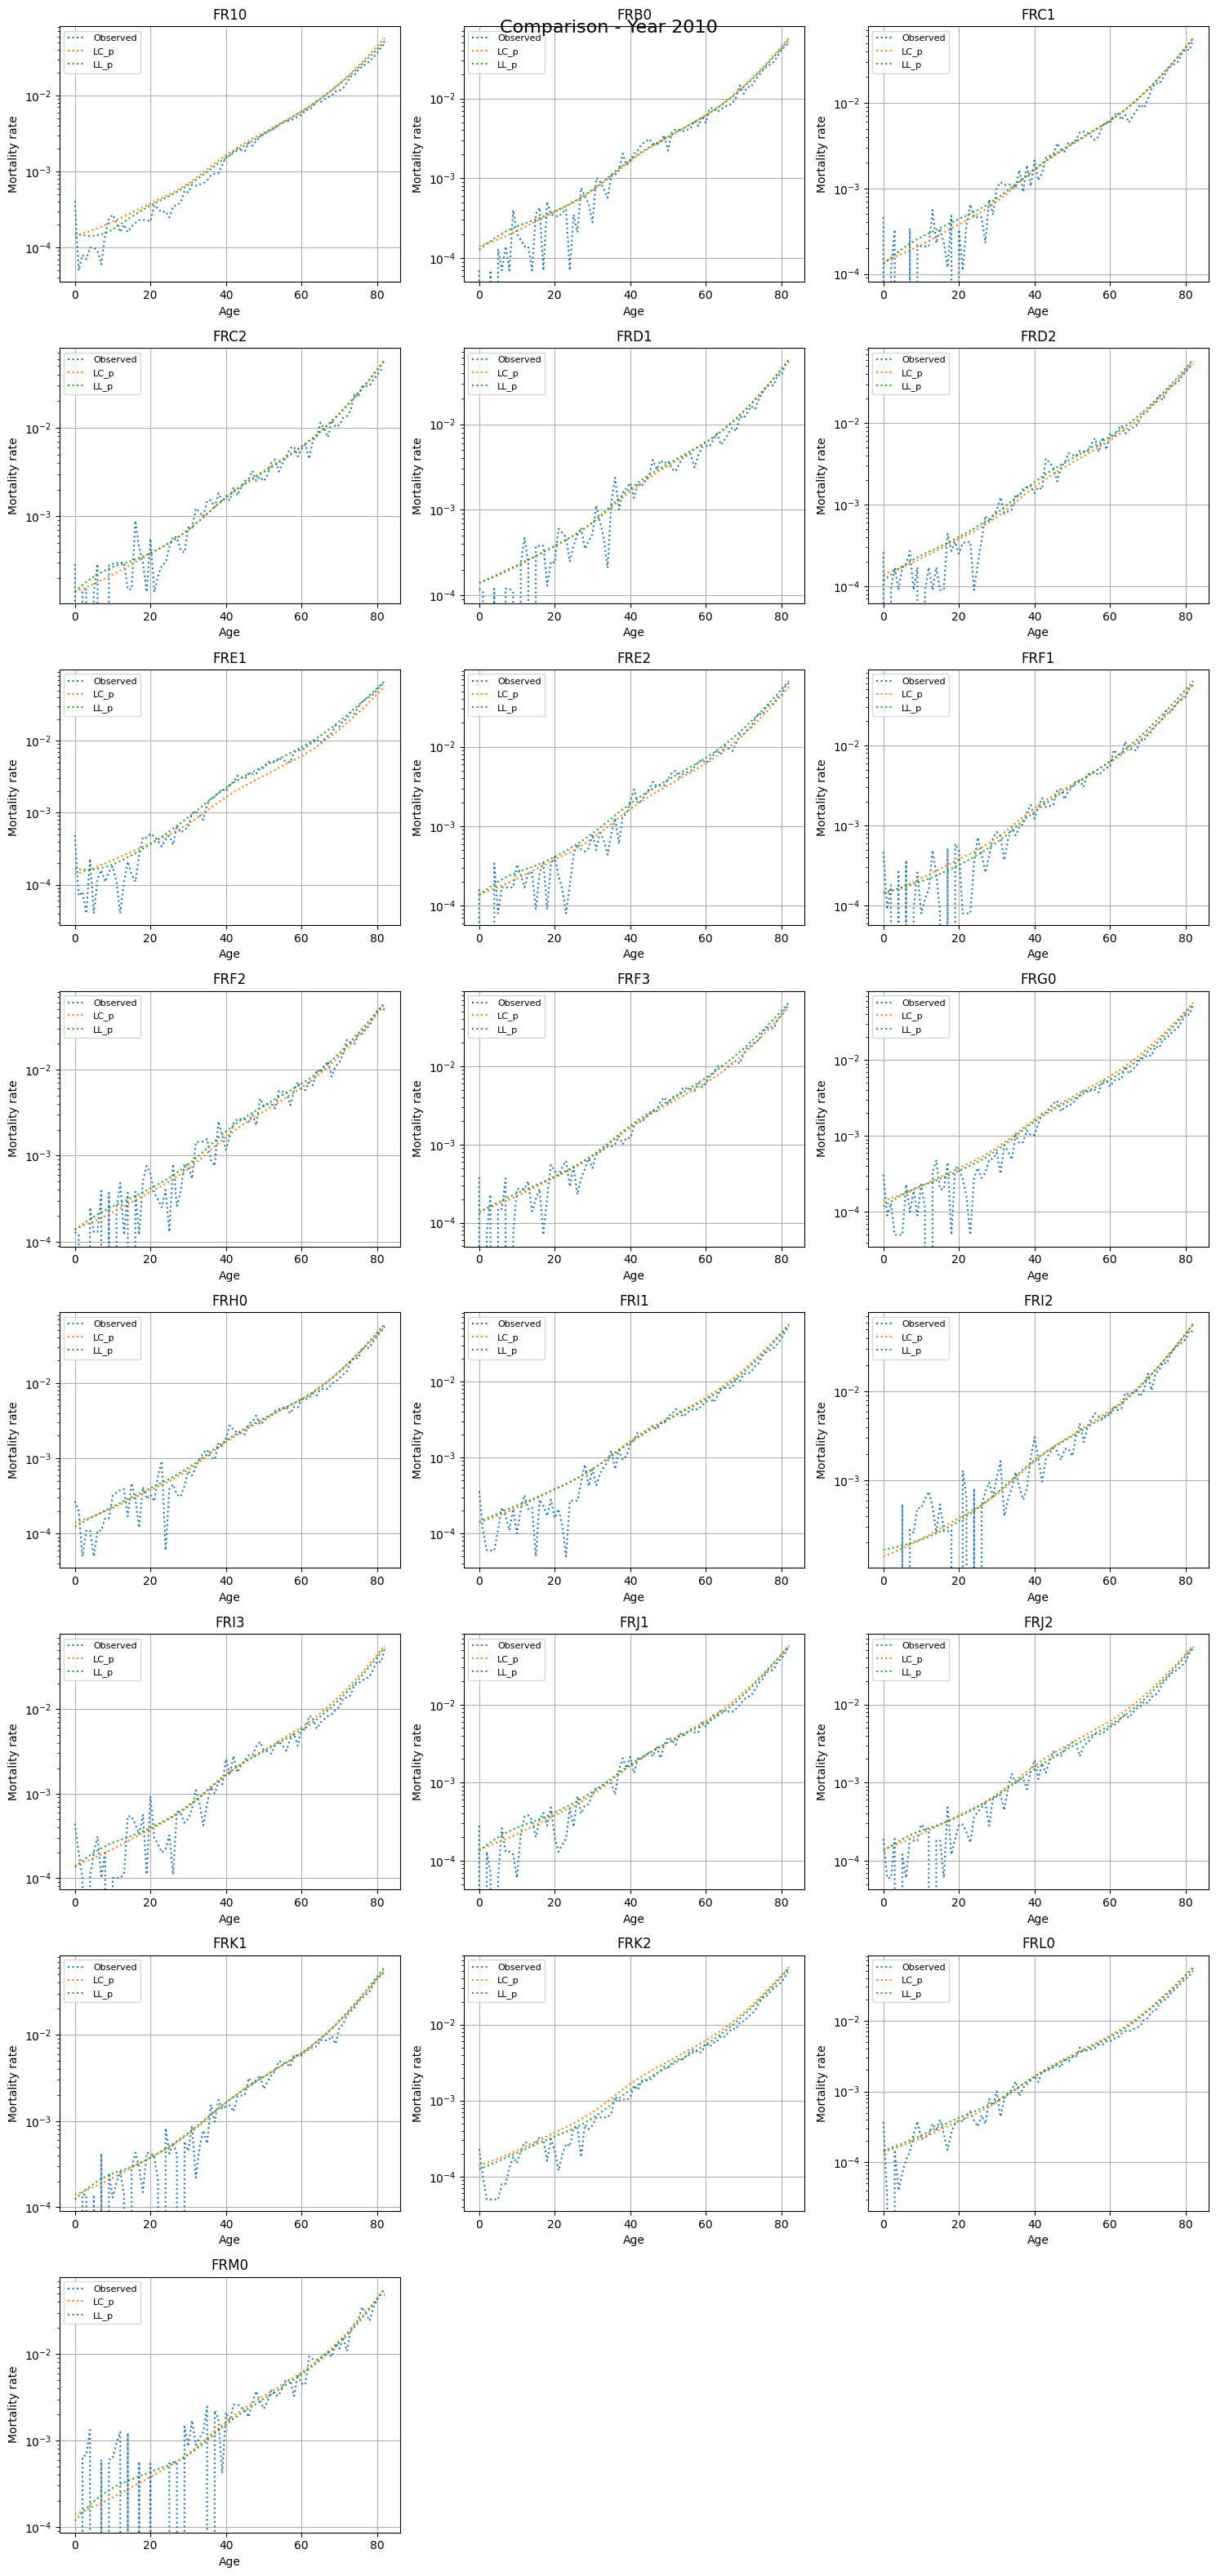

In [21]:
plot_models_by_region(
    x_values=xv,
    curves_dict=curves,
    year_to_plot=2010,
    tv=tv,
    regions=regions
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu_obs = Dxtg / Extg

def plot_all_regions(year_to_plot):
    
    if year_to_plot not in tv:
        raise ValueError(f"Année {year_to_plot} non disponible.")
    
    t_index = np.where(tv == year_to_plot)[0][0]
    
    n_regions = len(regions)
    n_cols = 3
    n_rows = int(np.ceil(n_regions / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    
    # Sécurise le cas où il n'y a qu'une seule ligne
    if n_rows == 1:
        axes = np.array(axes).reshape(-1)
    else:
        axes = axes.flatten()
    
    for g, region_name in enumerate(regions):
        
        ax_plot = axes[g]
        
        # Courbe observée
        ax_plot.plot(
            xv, 
            mu_obs[:, t_index, g],
            label="Observé",
            linewidth=2
        )
        
        # Lee-Carter
        ax_plot.plot(
            xv,
            mu_hat_lc[:, t_index, g],
            label="LC",
            linestyle="--"
        )
        
        # LC pénalisé
        ax_plot.plot(
            xv,
            result_lcp['fitted_values']['mu'][:, t_index, g],
            label="LC_p",
            linestyle="-."
        )
        
        # Li-Lee pénalisé
        ax_plot.plot(
            xv,
            resultat_llp["fitted_values"]['mu'][:, t_index, g],
            label="LL_p",
            linestyle=":"   # <-- corrigé (au lieu de "..")
        )
        
        ax_plot.set_title(region_name)
        ax_plot.set_yscale("log")
        ax_plot.set_xlabel("Age")
        ax_plot.set_ylabel("Mortality rate")
        ax_plot.grid(True)
        ax_plot.legend(fontsize=8)
    
    # Supprimer axes inutilisés
    for i in range(n_regions, len(axes)):
        fig.delaxes(axes[i])
    
    fig.suptitle(
        f"Taux observé vs LC vs LC_p - année {year_to_plot}",
        fontsize=16
    )
    
    plt.tight_layout()
    plt.show()


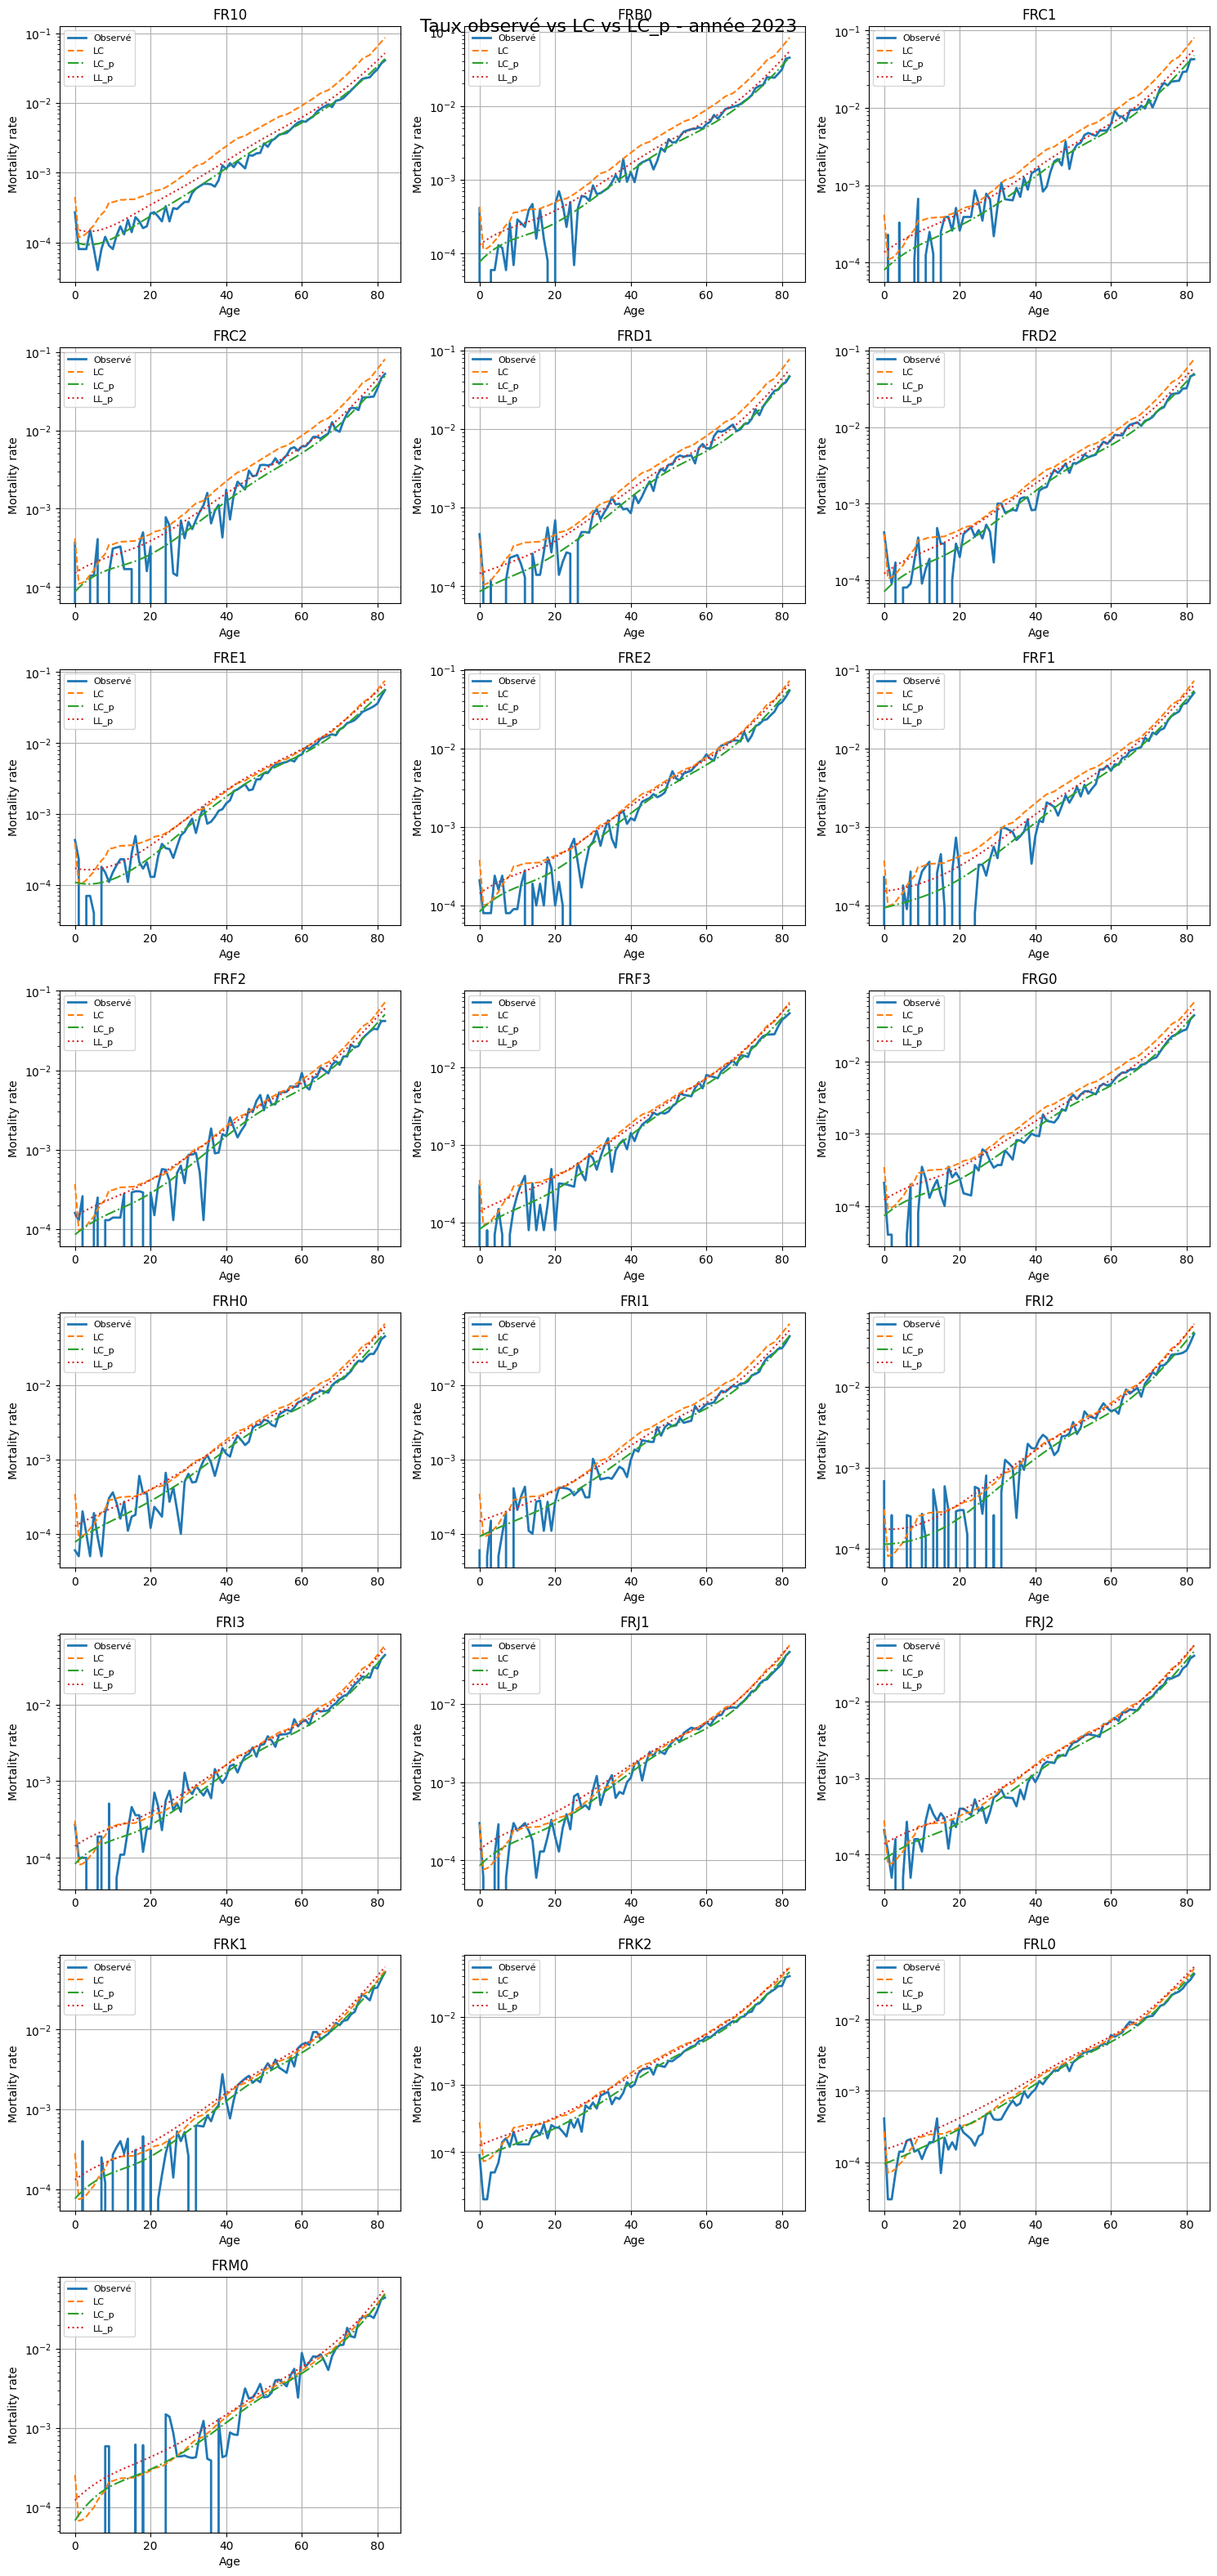

In [31]:
plot_all_regions(2023)
#plot_all_regions(2020)
#plot_all_regions(2023)


### Annexes

In [51]:
shapef = gpd.read_file("C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp")
stock = "C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data"
mxt_raw = load_mxt_raw(shapef,country="FR",data_path=stock)
Dxt_raw = load_dxt_raw(shapef,country="FR",data_path=stock)
Lxt_raw = load_lxt_raw(shapef,country="FR",data_path=stock)

[Eurostat] Téléchargé → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_mxt_raw_FR.csv  (1,543,872 lignes)
[Eurostat] Chargé depuis cache → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_Dxt_raw_FR.csv  (231,132 lignes)
[Eurostat] Téléchargé → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_Lxt_raw_FR.csv  (244,728 lignes)
